In [9]:
import os

import psycopg
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mlflow
from dotenv import load_dotenv

load_dotenv()

TABLE_NAME = "users_churn"  # таблица с данными в postgres

TRACKING_SERVER_HOST = "127.0.0.1"
TRACKING_SERVER_PORT = 5003

EXPERIMENT_NAME = "EDA_EXPERIMENT"  # напишите название вашего эксперимента
RUN_NAME = "eda_run1"

ASSETS_DIR = "assets"

if not os.path.exists(ASSETS_DIR):
    os.mkdir(ASSETS_DIR)  # или os.makedirs(ASSETS_DIR, exist_ok=True)

pd.options.display.max_columns = 100
pd.options.display.max_rows = 64

sns.set_style("white")
sns.set_theme(style="whitegrid")

connection = {"sslmode": "require", "target_session_attrs": "read-write"}
postgres_credentials = {
    "host": os.getenv("DB_DESTINATION_HOST"),
    "port": os.getenv("DB_DESTINATION_PORT"),
    "dbname": os.getenv("DB_DESTINATION_NAME"),
    "user": os.getenv("DB_DESTINATION_USER"),
    "password": os.getenv("DB_DESTINATION_PASSWORD"),
}

connection.update(postgres_credentials)

with psycopg.connect(**connection) as conn:

    with conn.cursor() as cur:
        cur.execute(f"SELECT * FROM {TABLE_NAME}")
        data = cur.fetchall()
        columns = [col[0] for col in cur.description]

df = pd.DataFrame(data, columns=columns)

df.head(2)

,id,customer_id,begin_date,end_date,type,paperless_billing,payment_method,monthly_charges,total_charges,internet_service,online_security,online_backup,device_protection,tech_support,streaming_tv,streaming_movies,gender,senior_citizen,partner,dependents,multiple_lines,target
0,1,7590-VHVEG,2020-01-01,NaT,Month-to-month,Yes,Electronic check,29.85,29.85,DSL,No,Yes,No,No,No,No,Female,0,Yes,No,None,0
1,2,5575-GNVDE,2017-04-01,NaT,One year,No,Mailed check,56.95,1889.50,DSL,Yes,No,Yes,No,No,No,Male,0,No,No,No,0


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

data = sns.load_dataset("planets")

# количество планет в каждом году
sns.catplot(
    data=data,
    x="year",
    kind="count",  # Изменили "bar" на "point"
)
plt.title("Количество планет в каждом году")
plt.savefig("catplot.png")
plt.show()

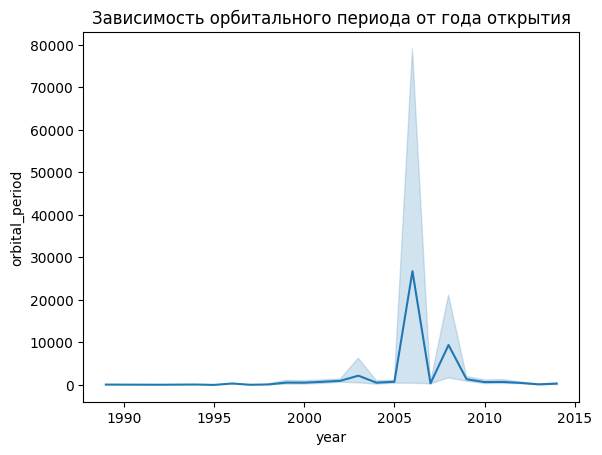

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

data = sns.load_dataset("planets")

# количество планет в каждом году
sns.lineplot(data=data, x="year", y="orbital_period")
plt.title("Зависимость орбитального периода от года открытия")
plt.show()

Text(0.5, 1.0, 'Гистограмма распределения массы экзопланет')

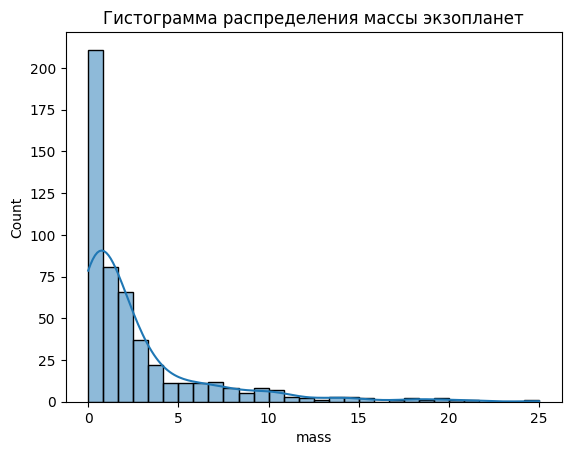

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

# загрузка данных
data = sns.load_dataset("planets")


# ваш код здесь
sns.histplot(data=data.dropna(subset="mass"), x="mass", bins=30, kde=True)
plt.title("Гистограмма распределения массы экзопланет")
# plt.show()

/Users/sergeyuser/Documents/Yandex Практикум/проекты/sprint2_part2_data/.venv/lib/python3.10/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but Normalizer was fitted without feature names
  warnings.warn(


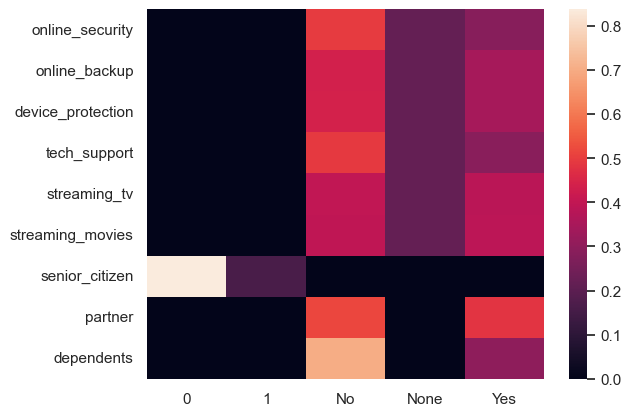

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import Normalizer

transformer = Normalizer(norm="l1")


x = "customer_id"
binary_columns = [
    "online_security",
    "online_backup",
    "device_protection",
    "tech_support",
    "streaming_tv",
    "streaming_movies",
    "senior_citizen",
    "partner",
    "dependents",
]
stat = ["count"]

heat_df = (
    df[binary_columns].astype(str).apply(pd.Series.value_counts).T.fillna(0)
)

transformer = Normalizer(norm="l1")

# 3. Трансформируем данные.
# На выходе получаем numpy-массив, поэтому сразу оборачиваем его обратно в DataFrame
normalized_values = transformer.transform(heat_df)
heat_df_norm = pd.DataFrame(
    normalized_values, columns=heat_df.columns, index=heat_df.index
)

sns.heatmap(heat_df_norm)
plt.savefig(os.path.join(ASSETS_DIR, "cat_features_2_binary_heatmap"))

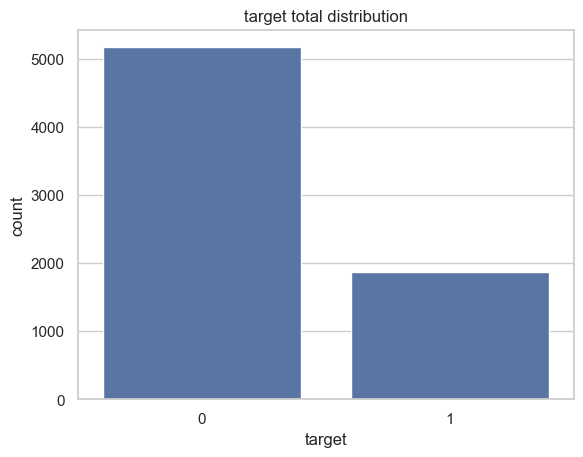

In [16]:
# директория для сохранения картинок
ASSETS_DIR = "assets"  # ваш код здесь #

# установка названия колонки для агрегации
x = "target"

# подсчёт количества каждого уникального значения в колонке и сброс индекса для последующей визуализации
target_agg = df[x].value_counts().reset_index()  # ваш код здесь #
target_agg.columns = [x, "count"]

# создание столбчатой диаграммы для визуализации распределения целевой переменной
# ваш код здесь #
sns.barplot(data=target_agg, x=x, y="count")

# установка заголовка графика
plt.title(f"{x} total distribution")

# сохранение графика в файл
# ваш код здесь #
plt.savefig(os.path.join(ASSETS_DIR, "target_count"))